In [1]:
# Add the parent directory of the current working directory to the Python path at runtime. 
# In order to import modules from the src directory.
import os
import sys 

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.insert(0, parent_dir)

In [2]:
import torch

import tomllib
import leidenalg
import pandas as pd
import numpy as np
import igraph as ig
from copy import deepcopy

import matplotlib.pyplot as plt

from scipy.optimize import nnls


from langchain_ollama import OllamaLLM
from langchain_core.prompts import PromptTemplate
from src.utils.clustering import construct_knn_graph
from src.classes.sparse_embedding_network import SparseEmbeddingNetwork
from langchain_voyageai.embeddings import VoyageAIEmbeddings
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())
voyage_api_key = os.environ["VOYAGE_API_KEY"]

BASEPATH = os.environ["BASEPATH"]

/home/mario/miniconda3/envs/trends_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def parse_directories():
    """
    Parse the directories from the configuration file.
    Returns:
    - directories: dict
    """
    with open('../config/directories.toml', 'rb') as f:
        configurations = tomllib.load(f)

    return configurations

In [4]:
directories = parse_directories()
model_path = os.path.join(BASEPATH, directories['public']['models'])
model_file = os.path.join(model_path, "domain_embedding_model.pth")

In [5]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [6]:
batch_size = 25
voyage_embedder = VoyageAIEmbeddings(model='voyage-large-2-instruct', batch_size=batch_size,
                                         voyage_api_key=voyage_api_key)

# define the model and load the pre-trained weights
input_dimension = 1024
hidden_dimensions =  [512, 256, 128]
output_dimension = 64

model = SparseEmbeddingNetwork(input_dimension=input_dimension,
                                 hidden_dimensions=hidden_dimensions,
                                 output_dimension=output_dimension).to(device)

model.load_state_dict(torch.load(model_file, map_location=device))
model.eval()

def embed_abstracts(abstracts, voyage_embedder, model, device, batch_size=25):
    """
    Embed a list of abstracts using the VoyageAI embedder and the sparse embedding model.

    Args:
    - abstracts: List of abstracts to embed.
    - voyage_embedder: The VoyageAI embedder to use.
    - model: The sparse embedding model to use.
    - device: The device to use (CPU or GPU).

    Returns:
    - embeddings: Numpy array of embeddings.
    """

    num_abstracts = len(abstracts)
    all_embeddings = []
    for i in range(0, num_abstracts, batch_size):
        batch_abstracts = abstracts[i:i+batch_size]
        batch_embeddings = voyage_embedder.embed_documents(batch_abstracts)
        batch_embeddings = torch.tensor(batch_embeddings, dtype=torch.float32).to(device)
        with torch.no_grad():
            batch_embeddings = model(batch_embeddings).cpu().numpy()
        all_embeddings.append(batch_embeddings)

    embeddings = np.vstack(all_embeddings)
    return embeddings

In [49]:
bonte_abstracts = [
    """Speaking involves the orchestration of multiple speech muscles while actively monitoring sensory consequences through auditory and somatosensory feedback. A mistuned sensorimotor mechanism may disrupt the normal integration of motor and auditory brain systems in several developmental and acquired motor speech disorders, including stuttering, speech apraxia, speech sound disorders and dysarthria. Electroencephalography (EEG) provides a non-invasive measure of online neural activity with potential to assess (deficiencies in) sensorimotor integration during speech production. However, the relation between EEG and continuous speechoutput remains poorly characterized. Here, we investigate prediction of auditory speech output using multivariate EEG patterns under three levels of auditory masking. A decoding analysis was employed in combination with a lag-based approach that allowed studying predictions based on instantaneous EEG-speech relations, and their involvement in feedforward and feedback processes. For all masking conditions, we found consistent decoding in instantaneous lags and speech feedback lags, but not in feedforward lags. Furthermore, the level of auditory masking modulated decoding in both the instantaneous and feedback lags. Our results provide insights of neural monitoring during online speech production and offer a window to further study the dysfunction latent in motor speech disorders that may help in optimizing brain-informed therapies for speech fluency.""",
    """Children show an enormous capacity to learn during development, but with large individual differences in the time course and trajectory of learning and the achieved skill level. Recent progress in developmental sciences has shown the contribution of a multitude of factors including genetic variation, brain plasticity, socio-cultural context and learning experiences to individual development. These factors interact in a complex manner, producing children's idiosyncratic and heterogeneous learning paths. Despite an increasing recognition of these intricate dynamics, current research on the development of culturally acquired skills such as reading still has a typical focus on snapshots of children’s performance at discrete points in time. Here we argue that this ‘static’ approach is often insufficient and limits advancements in the prediction and mechanistic understanding of individual differences in learning capacity. We present a dynamic framework which highlights the importance of capturing short-term trajectories during learning across multiple stages and processes as a proxy for long-term development on the example of reading. This framework will help explain relevant variability in children’s learning paths and outcomes and fosters new perspectives and approaches to study how children develop and learn.""",
    """The acquisition of letter–speech sound correspondences is a fundamental process underlying reading development, one that could be influenced by several linguistic and domain-general cognitive factors. In the current study, we mimicked the first steps of this process by examining behavioral trajectories of audiovisual associative learning in 110 7- to 12-year-old children with and without dyslexia. Children were asked to learn the associations between eight novel symbols and native speech sounds in a brief training and subsequently read words and pseudowords written in the artificial orthography. We then investigated the influence of auditory attention as one of the putative domain-general factors influencing associative learning. To this aim, we assessed children with experimental measures of auditory sustained selective attention and interference control. Our results showed shallower learning trajectories in children with dyslexia, especially during the later phases of the training blocks. Despite this, children with dyslexia performed similarly to typical readers on the post-training reading tests using the artificial orthography. Better auditory sustained selective attention and interference control skills predicted greater response accuracy during training. Sustained selective attention was also associated with the ability to apply these novel correspondences in the reading tests. Although this result has the limitations of a correlational design, it denotes that poor attentional skills may constitute a risk during the early stages of reading acquisition, when children start to learn letter–speech sound associations. Importantly, our findings underscore the importance of examining dynamics of learning in reading acquisition as well as individual differences in more domain-general attentional factors.""",
    """Auditory selective attention forms an important foundation of children's learning by enabling the prioritisation and encoding of relevant stimuli. It may also influence reading development, which relies on metalinguistic skills including the awareness of the sound structure of spoken language. Reports of attentional impairments and speech perception difficulties in noisy environments in dyslexic readers are also suggestive of the putative contribution of auditory attention to reading development. To date, it is unclear whether non-speech selective attention and its underlying neural mechanisms are impaired in children with dyslexia and to which extent these deficits relate to individual reading and speech perception abilities in suboptimal listening conditions. In this EEG study, we assessed non-speech sustained auditory selective attention in 106 7-to-12-year-old children with and without dyslexia. Children attended to one of two tone streams, detecting occasional sequence repeats in the attended stream, and performed a speech-in-speech perception task. Results show that when children directed their attention to one stream, inter-trial-phase-coherence at the attended rate increased in fronto-central sites; this, in turn, was associated with better target detection. Behavioural and neural indices of attention did not systematically differ as a function of dyslexia diagnosis. However, behavioural indices of attention did explain individual differences in reading fluency and speech-in-speech perception abilities: both these skills were impaired in dyslexic readers. Taken together, our results show that children with dyslexia do not show group-level auditory attention deficits but these deficits may represent a risk for developing reading impairments and problems with speech perception in complex acoustic environments.""",
    """Several theories of predictive processing propose reduced sensory and neural responses to anticipated events. Support comes from magnetoencephalography/electroencephalography (M/EEG) studies, showing reduced auditory N1 and P2 responses to self-generated compared to externally generated events, or when the timing and form of stimuli are more predictable. The current study examined the sensitivity of N1 and P2 responses to statistical speech regularities. We employed a motor-to-auditory paradigm comparing event-related potential (ERP) responses to externally and self-triggered pseudowords. Participants were presented with a cue indicating which button to press (motor–auditory condition) or which pseudoword would be presented (auditory-only condition). Stimuli consisted of the participant's own voice uttering pseudowords that varied in phonotactic probability and syllable stress. We expected to see N1 and P2 suppression for self-triggered stimuli, with greater suppression effects for more predictable features such as high phonotactic probability and first-syllable stress in pseudowords. In a temporal principal component analysis (PCA), we observed an interaction between syllable stress and condition for the N1, where second-syllable stress items elicited a larger N1 than first-syllable stress items, but only for externally generated stimuli. We further observed an effect of syllable stress on the P2, where first-syllable stress items elicited a larger P2. Strikingly, we did not observe motor-induced suppression for self-triggered stimuli for either the N1 or P2 component, likely due to the temporal predictability of the stimulus onset in both conditions. Taking into account previous findings, the current results suggest that sensitivity to syllable stress regularities depends on task demands.""",
    """Learning to read impacts the way the ventral occipitotemporal cortex (VOT) reorganizes.
The postulated underlying mechanism of neuronal recycling was recently revisited. Neu-
roimaging data showed that voxels weakly specialized for visual processing keep their
initial category selectivity (i.e., object or face processing) while acquiring an additional and
stronger responsivity to written words. Here, we examined a large and diverse group of six-
year-olds prior to formal literacy training (N ¼ 72) using various data analysis techniques
(univariate, multivariate, rapid adaptation) and types of stimuli (print, false fonts, houses,
faces) to further explore how VOT changes and adapts to the novel skill of reading. We
found that among several visual stimuli categories only print activated a wide network of
language related areas outside of the bilateral visual cortex, and the level of reading skill
was related to the strength of this activation, showing the development of the reading
circuit. Rapid adaptation was not directly related to the level of reading skill in the young
children studied here, but it clearly revealed the emergence of the reading network in
readers. Most importantly, we found that the reorganization of the VOT is not in fact an
“invasion” by reading acquisitionevoxels previously activated for faces started to respond
more for print, while at the same time keeping their previous function. We can thus
conclude that the revised hypothesis of neuronal recycling is supported by our data.""",
 """Developmental dyslexia is often accompanied by altered phonological processing of speech. Underlying neural changes have typically been characterized in terms of stimulus- and/or task-related responses within individual brain regions or their functional connectivity. Less is known about potential changes in the more global functional organization of brain networks. Here we recorded electroencephalography (EEG) in typical and dyslexic readers while they listened to (a) a random sequence of syllables and (b) a series of tri-syllabic real words. The network topology of the phase synchronization of evoked cortical oscillations was investigated in four frequency bands (delta, theta, alpha and beta) using minimum spanning tree graphs. We found that, compared to syllable tracking, word tracking triggered a shift toward a more integrated network topology in the theta band in both groups. Importantly, this change was significantly stronger in the dyslexic readers, who also showed increased reliance on a right frontal cluster of electrodes for word tracking. The current findings point towards an altered effect of word-level processing on the functional brain network organization that may be associated with less efficient phonological and reading skills in dyslexia."""
]

In [7]:
abstracts_df = pd.read_excel('~/Downloads/cn_abstracts.xlsx')

In [51]:
abstracts = abstracts_df['Abstract (just copy-paste the text of your abstract in an empty cell below - one abstract per cell)'].tolist()
abstracts += bonte_abstracts
# remove duplicate abstracts
abstracts = list(set(abstracts))

embeddings = embed_abstracts(abstracts, voyage_embedder, model, device, batch_size=batch_size)

In [52]:
remove_indices = []
for i, (abstract, embedding) in enumerate(zip(abstracts, embeddings)):
    similarities = np.dot(embeddings, embedding)
    similarities[i] = 0.0
    # similarity above 0.99 indicates duplicate
    duplicates = np.where(similarities > 0.99)[0]
    if len(duplicates) > 0:
        print(f'Abstract {i} has duplicates: {duplicates.tolist()}')
        remove_indices.extend(duplicates.tolist())

embeddings = np.delete(embeddings, remove_indices, axis=0)
abstracts = [abstract for i, abstract in enumerate(abstracts) if i not in remove_indices]

Abstract 17 has duplicates: [35]
Abstract 29 has duplicates: [148]
Abstract 35 has duplicates: [17]
Abstract 42 has duplicates: [125]
Abstract 54 has duplicates: [60]
Abstract 59 has duplicates: [132]
Abstract 60 has duplicates: [54]
Abstract 62 has duplicates: [88]
Abstract 88 has duplicates: [62]
Abstract 99 has duplicates: [101]
Abstract 101 has duplicates: [99]
Abstract 125 has duplicates: [42]
Abstract 132 has duplicates: [59]
Abstract 148 has duplicates: [29]


Aims: To measure brain activity in patients with bruxism and temporomandibular disorder (TMD)–related pain in comparison to controls using functional magnetic resonance imaging (fMRI) and to investigate whether modulations in jaw clenching led to different pain reports and/or changes in neural activity in motor and pain processing areas within and between both groups. Methods: A total of 40 participants (21 patients with bruxism and TMD-related pain and 19 healthy controls) performed a tooth-clenching task while lying inside a 3T MRI scanner. Participants were instructed to mildly or strongly clench their teeth for brief periods of 12 seconds and to subsequently rate their clenching intensity and pain experience after each clenching period. Results: Patients reported significantly more pain during strong clenching compared to mild clenching. Further results showed significant differences between patients and controls in activity in areas of brain networks commonly associated with pain 

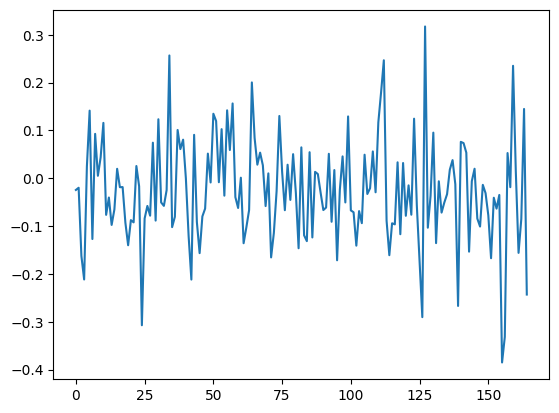

In [63]:
similarities = np.dot(embeddings, embeddings.T)
np.fill_diagonal(similarities, 0.0)

idx = np.argmin(np.max(similarities, axis=1))
print(abstracts[idx])
plt.plot(similarities[idx])

In [53]:
num_neighbors = 4

    
edges, weights = construct_knn_graph(embeddings, num_neighbors)
G = ig.Graph(edges=edges, directed=False)
G.es['weight'] = weights

Performing k-NN search...
Constructing edge list...


100%|██████████| 165/165 [00:00<00:00, 90726.29it/s]


Symmetrizing the graph...


100%|██████████| 165/165 [00:00<00:00, 240215.26it/s]


In [54]:
partition = leidenalg.find_partition(
            G,
            leidenalg.CPMVertexPartition,
            weights='weight',
            resolution_parameter=0.04)
print(f'modularity: {partition.modularity}')
print(f'found {len(np.unique(partition.membership))} clusters')

modularity: 0.7677692210579472
found 20 clusters


In [55]:
clusters = np.unique(partition.membership)

for cluster in clusters:
    cluster_abstracts = [abstracts[i] for i in range(len(abstracts)) if partition.membership[i] == cluster]
    print(f'\nCluster {cluster} abstracts:')
    for abstract in cluster_abstracts:
        print(f'- {abstract}')


Cluster 0 abstracts:
- In everyday life, the brain uses contextual information to predict future events. Various theories, including predictive coding, propose that this process is supported by an (internal) model of the (sensory) world through computations across the cortical microcircuit. There is ample evidence for these processes at the behavioral and computational levels, yet most laminar evidence comes from animal studies. Because human cortical microcircuits differ substantially from those of nonhuman species, determining how predictions and errors are generated in the human brain remains crucial and largely unknown. Using ultra–high-field (7 T) laminar fMRI, and an extensive cortical coverage, we asked where and in which cortical depths auditory predictions and prediction errors are processed. Participants learned that visual cues predicted specific auditory syllables, which were occasionally invalid or omitted. Invalid syllables elicited stronger superficial layer activity in

median similarity in cluster 1: 0.35254403948783875


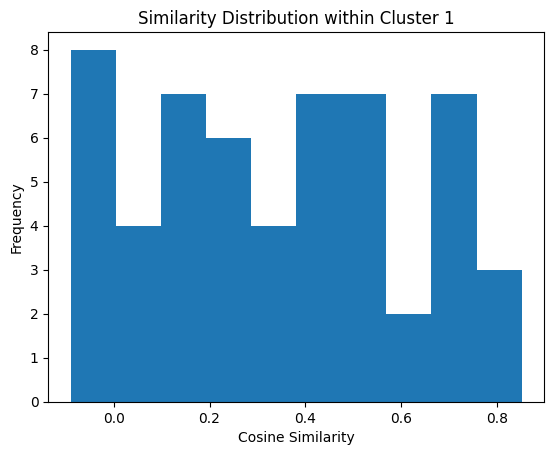

In [32]:
cluster_of_interest = 1
intra_cluster_indices = [i for i in range(len(abstracts)) if partition.membership[i] == cluster_of_interest]
intra_cluster_embeddings = embeddings[intra_cluster_indices]
similarity_matrix = np.dot(intra_cluster_embeddings, intra_cluster_embeddings.T)
mask = np.triu(np.ones_like(similarity_matrix, dtype=bool))

print(f'median similarity in cluster {cluster_of_interest}: {np.median(similarity_matrix[~mask])}')

plt.hist(similarity_matrix[~mask].flatten(), bins=10)
plt.title(f'Similarity Distribution within Cluster {cluster_of_interest}')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency') 
plt.show()

In [75]:
import numpy as np
from sklearn.mixture import GaussianMixture

# Assume 'embeddings' is your (N, D) numpy array
# embeddings = np.ascontiguousarray(embeddings, dtype=np.float32)

# 1. Initialize and fit the GMM
# n_components is the number of clusters (distributions) you want to find.
num_clusters = 10
gmm = GaussianMixture(n_components=num_clusters, random_state=42)
gmm.fit(embeddings)

# 2. Get the fuzzy cluster assignments (probabilities)
# This returns an (N, num_clusters) array where each row sums to 1.
membership_probabilities = gmm.predict_proba(embeddings)

# Let's inspect the membership for the first abstract
abstract_0_probs = membership_probabilities[4]
print("Membership probabilities for the first abstract:")
for i, prob in enumerate(abstract_0_probs):
    print(f"  Cluster {i}: {prob:.4f}")

# You can still get a "hard" assignment if you need it
hard_labels = gmm.predict(embeddings)

Membership probabilities for the first abstract:
  Cluster 0: 0.0000
  Cluster 1: 0.0000
  Cluster 2: 0.0000
  Cluster 3: 0.0000
  Cluster 4: 0.0000
  Cluster 5: 0.0000
  Cluster 6: 0.0000
  Cluster 7: 1.0000
  Cluster 8: 0.0000
  Cluster 9: 0.0000


In [86]:
!pip install bertopic
# You might also need hdbscan if it's not installed as a dependency


  Using cached pynndescent-0.5.13-py3-none-any.whl.metadata (6.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 6.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 8.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 9.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 8.8 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 8.9 MB/s eta 0:00:00ta 0:00:01
Using cached pynndescent-0.5.13-py3-none-any.whl (56 kB)
  Attempting uninstall: huggingface-hub━━━━━━━━━━━━━━━━━━━━━━━━━━━  2/11 [numba]te]
    Found existing installation: huggingface-hub 0.33.4━━━━━━━  2/11 [numba]
    Uninstalling huggingface-hub-0.33.4:━━━━━━━━━━━━━━━━━━━━━━  2/11 [numba]
      Successfully uninstalled huggingface-hub-0.33.4━━━━━━━━━  2/11 [numba]
  Attempting uninstall: tokenizers90m━━━━━━━━━━

In [87]:
import numpy as np
from bertopic import BERTopic

# Assume 'abstracts' is your list of original abstract strings
# Assume 'embeddings' is your final (N, D) numpy array from your model
#
# abstracts = ["The first abstract...", "The second abstract...", ...]
# embeddings = embed_abstracts(...) # Your function from before

# --- Ensure embeddings are in the correct format ---
# BERTopic prefers float64 for some internal calculations with UMAP/HDBSCAN,
# but float32 often works fine. Let's be safe.
embeddings = np.ascontiguousarray(embeddings, dtype=np.float64)


# --- Initialize BERTopic to use your pre-computed embeddings ---
# We tell BERTopic not to use an internal embedding model. The modern way is to
# pass embedding_model="passthrough".
topic_model = BERTopic(embedding_model="passthrough", 
                       verbose=True)

# --- Fit the model and find topics ---
# You MUST pass both the documents (abstracts) and their embeddings
topics, probs = topic_model.fit_transform(abstracts, embeddings)

# --- Now, explore the results ---

# `topics` is a list of the primary topic assignment for each document (the "hard" clustering)
# `probs` is the matrix of membership probabilities (the "fuzzy" clustering you wanted!)

print(f"Shape of probability matrix: {probs.shape}") # (num_documents, num_topics)
print("\n--- Topic Info ---")
# Get a dataframe with information about each topic found
# It shows the topic ID, count, and the words that define it.
print(topic_model.get_topic_info())

print("\n--- Topic for First Abstract ---")
# Get the main topic for the first abstract
first_doc_topic = topic_model.get_topic(0) 
print(f"Main topic for abstract 0: {first_doc_topic}")

print("\n--- Probabilities for First Abstract ---")
# Get the fuzzy probabilities for the first abstract
# This is a dense array showing the probability of belonging to each topic.
# NOTE: BERTopic uses HDBSCAN which allows for outlier documents. 
# Probabilities might not sum to 1 if the document is considered an outlier.
first_doc_probs = topic_model.get_document_info(abstracts[0])
print(first_doc_probs)


# BERTopic also has amazing visualization tools (run this in a Jupyter Notebook)
# topic_model.visualize_topics()
# topic_model.visualize_distribution(probs[0]) # Visualize probs for the first doc

No sentence-transformers model found with name sentence-transformers/passthrough. Creating a new one with mean pooling.


OSError: sentence-transformers/passthrough is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`

In [88]:
import numpy as np
from bertopic import BERTopic
from bertopic.backend import BaseEmbedder

# Assume 'abstracts' and 'embeddings' are already defined
# abstracts = ["The first abstract...", "The second abstract...", ...]
# embeddings = embed_abstracts(...) 

# --- 1. Create a dummy embedder class ---
# This class satisfies BERTopic's need for an "embedding model" object
# but its embed method will never be called because we provide the embeddings directly.
class DummyEmbedder(BaseEmbedder):
    def embed(self, documents, verbose=False):
        # This method is required by the abstract base class, but it won't be used.
        # We can just return the pre-computed embeddings if we really want,
        # but it's cleaner to just have it pass.
        pass

# --- 2. Initialize BERTopic with an instance of the dummy embedder ---
# This is the key change. Instead of a string, we pass an object.
dummy_model = DummyEmbedder()
topic_model = BERTopic(embedding_model=dummy_model, 
                       verbose=True)

# --- 3. Fit the model (this part is the same) ---
# You still MUST pass both the documents and their embeddings
topics, probs = topic_model.fit_transform(abstracts, embeddings)

# --- 4. Explore the results (this part is the same) ---
print("--- Topic Info ---")
print(topic_model.get_topic_info())

print("\n--- Topic for First Abstract ---")
first_doc_topic = topic_model.get_topic(0) 
print(f"Main topic for abstract 0: {first_doc_topic}")

2025-12-05 14:39:44,548 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-05 14:39:52,934 - BERTopic - Dimensionality - Completed ✓
2025-12-05 14:39:52,935 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-05 14:39:52,946 - BERTopic - Cluster - Completed ✓
2025-12-05 14:39:52,950 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-05 14:39:52,978 - BERTopic - Representation - Completed ✓


--- Topic Info ---
   Topic  Count                Name  \
0     -1     20    -1_and_the_of_to   
1      0     30      0_the_of_in_to   
2      1     14  1_the_of_memory_to   
3      2     12     2_the_and_in_of   
4      3     12   3_the_of_that_and   

                                      Representation  \
0  [and, the, of, to, in, with, fnirs, for, were,...   
1  [the, of, in, to, and, auditory, we, that, tac...   
2  [the, of, memory, to, conscious, in, and, by, ...   
3  [the, and, in, of, theta, stimulation, to, alp...   
4  [the, of, that, and, in, to, we, brain, as, co...   

                                 Representative_Docs  
0  [The same dataset can be analysed in different...  
1  [In everyday life, the processing of acoustic ...  
2  [The ability to detect and use environmental p...  
3  [Transcranial alternating current stimulation ...  
4  [Gamma oscillations are thought to play a key ...  

--- Topic for First Abstract ---
Main topic for abstract 0: [('the', np.float6

In [89]:
topic_model.visualize_topics()

In [90]:
topic_model.visualize_distribution(probs[0])

ValueError: This visualization cannot be used if you have set `calculate_probabilities` to False as it uses the topic probabilities of all topics. 